# Predictive Coding with convolutions

Minimal notebook setup for exploring predictive coding with NumPy, PyTorch, and torchvision.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
import math

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")

Using device: cpu
PyTorch: 2.13.0
NumPy: 2.5.2


dataset/input variables

In [53]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

input_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

Training Loop

In [54]:
def train_loop(I, r, alpha, lambda_u, lr_r, lr_u,sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs):
    I = I.float()
    if I.ndim == 3:
        I = I.unsqueeze(0)
    e = [None] * num_layers

    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    
    for out_epoch in range(num_epochs_outer):
        for in_epoch in range(num_epochs_inner):
            e[0] = I - deconvs[0](r[0])

            for i in range(1, num_layers):
                e[i] = r[i - 1] - deconvs[i](r[i])

            for i in range(num_layers):
                cauchy_prior = alpha * (2 * r[i] / (1 + r[i] ** 2))
                bottom_up = F.conv2d(e[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                dr = (1.0 / sigma_2) * bottom_up - cauchy_prior
                if i < num_layers - 1:
                    dr = dr - (1.0 / sigma_2) * e[i + 1]
                r[i] = (r[i] + lr_r * dr).detach()
                r[i].requires_grad = True

        e[0] = I - deconvs[0](r[0])
        
        for j in range(1, num_layers):
            e[j] = r[j - 1] - deconvs[j](r[j])
        
        loss = 0

        for j in range(num_layers):
            loss += (1.0 / (2 * sigma_2)) * torch.sum(e[j]**2)
            deconvs[j].zero_grad()
        

        loss.backward()

        with torch.no_grad():
            for j in range(num_layers):
                if deconvs[j].weight.grad is not None:
                    deconvs[j].weight -= lr_u * (deconvs[j].weight.grad + lambda_u * deconvs[j].weight)
                    deconvs[j].weight /= (torch.linalg.vector_norm(deconvs[j].weight, ord=2, dim=(1, 2, 3), keepdim=True) + 1e-8)
                    deconvs[j].weight.grad = None

    return r


validation


In [55]:
def validate_heirarchical(I, r, num_layers, deconvs):
    I = I.float()
    if I.ndim == 3:
        I = I.unsqueeze(0)
    
    I_hat_L0 = deconvs[0](r[0])
    
    h = r[num_layers - 1]
    for i in range(num_layers - 1, -1, -1):
        h = deconvs[i](h)
    I_hat_top_down = h
    
    mse_L0 = torch.mean((I - I_hat_L0) ** 2)
    mse_top_down = torch.mean((I - I_hat_top_down) ** 2)
    
    return mse_L0, mse_top_down, I_hat_L0, I_hat_top_down


In [56]:
def make_variables(image, initial_r_size=28, num_channels=16, num_layers=2, kernel_size=4, padding=1, stride=2):
    I = image
    r = []
    deconvs = []
    previous_num_channels = I.shape[0] if I.ndim == 3 else 1
    out_channels = num_channels * 2
    for i in range(num_layers):
        r_size = initial_r_size // (2 ** (i + 1))
        r.append(torch.randn(1, out_channels, r_size, r_size) * 0.01)
        deconvs.append(nn.ConvTranspose2d(out_channels, previous_num_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False))
        previous_num_channels = out_channels
        out_channels = out_channels * 2
    return I, r, deconvs

test it

In [57]:
def test(I, r, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs):
    I = I.float()
    if I.ndim == 3:
        I = I.unsqueeze(0)
    e = [None] * num_layers
    for in_epoch in range(num_epochs_inner):
        e[0] = I - deconvs[0](r[0])
        for i in range(1, num_layers):
            e[i] = r[i - 1] - deconvs[i](r[i])
        for i in range(num_layers):
            prior = alpha * (2 * r[i] / (1 + r[i] ** 2))
            bottom_up = F.conv2d(e[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
            dr = (1.0 / sigma_2) * bottom_up - prior
            if i < num_layers - 1:
                dr = dr - (1.0 / sigma_2) * e[i + 1]
            r[i] = (r[i] + lr_r * dr).detach()
            r[i].requires_grad = True
    return r


Starting Training: 20 Epochs | 100 Images | 2 Layers
Hyperparameters: lr_r=0.005, lr_U=0.002, alpha=0.001, lambda_u=0.001
[Epoch 000/020]  Layer 0 MSE: 0.001081 (|r0|: 0.0207)  |  Layer 1 MSE: 0.074961 (|r1|: 0.0094)


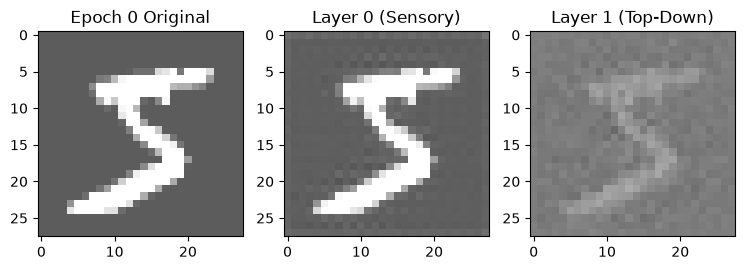

[Epoch 005/020]  Layer 0 MSE: 0.000161 (|r0|: 0.0208)  |  Layer 1 MSE: 0.012918 (|r1|: 0.0214)


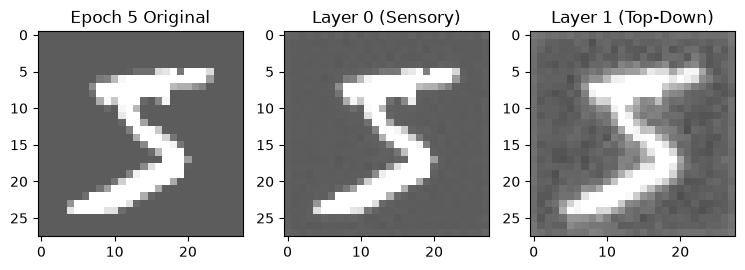

[Epoch 010/020]  Layer 0 MSE: 0.000067 (|r0|: 0.0222)  |  Layer 1 MSE: 0.003865 (|r1|: 0.0256)


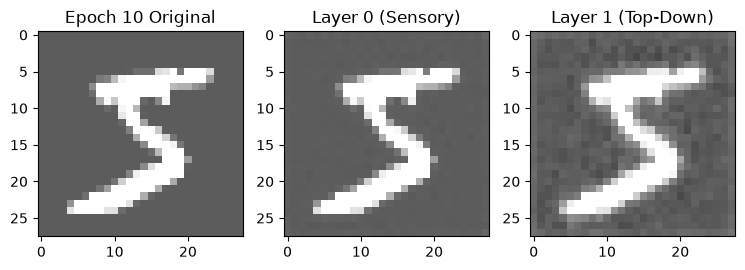

[Epoch 015/020]  Layer 0 MSE: 0.000034 (|r0|: 0.0230)  |  Layer 1 MSE: 0.001607 (|r1|: 0.0277)


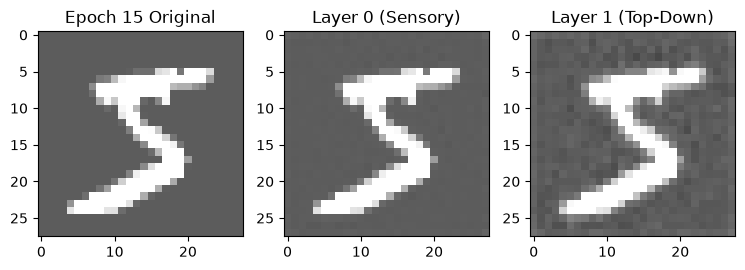

[Epoch 019/020]  Layer 0 MSE: 0.000021 (|r0|: 0.0235)  |  Layer 1 MSE: 0.000879 (|r1|: 0.0287)


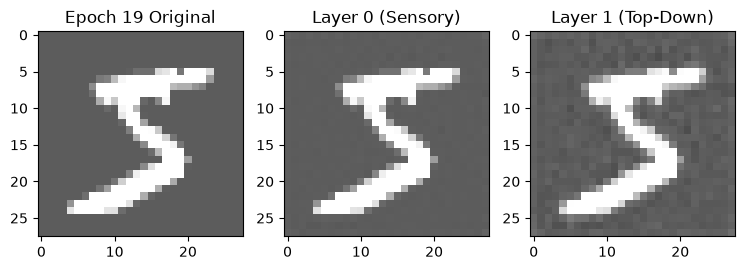

Validation Metrics  ->  Layer 0 MSE: 0.000867 (|r0|: 0.0145)  |  Layer 1 MSE: 0.041032 (|r1|: 0.0083)


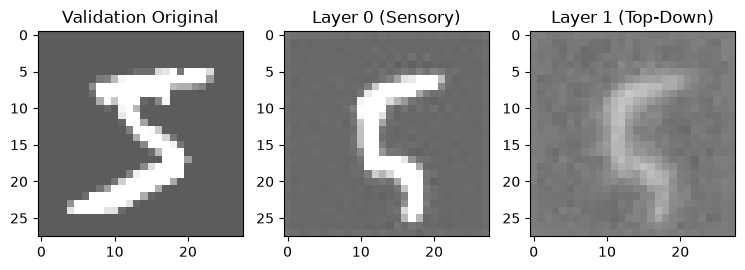

In [58]:
def main():
    num_data = 100
    images = [input_data[i][0] for i in range(num_data)]
    num_train_epochs = 20
    alpha = 0.001
    lambda_u = 0.001
    lr_r = 0.005
    lr_U = 0.002
    sigma_2 = 1.0
    num_layers = 2

    f = lambda x: x
    f_prime = lambda x: torch.ones_like(x)

    num_epochs_inner = 50
    num_epochs_outer = 1

    print("=" * 60)
    print(f"Starting Training: {num_train_epochs} Epochs | {num_data} Images | {num_layers} Layers")
    print(f"Hyperparameters: lr_r={lr_r}, lr_U={lr_U}, alpha={alpha}, lambda_u={lambda_u}")
    print("=" * 60)

    _, r_init, deconvs = make_variables(images[0], num_layers=num_layers)
    r_bank = [[ri.clone() for ri in r_init] for _ in images]
       
    for epoch in range(num_train_epochs):
        r0_list = []
        for i, image in enumerate(images):
            I = image - image.mean()
            r_bank[i] = train_loop(I, r_bank[i], alpha, lambda_u, lr_r, lr_U, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs)
            r0_list.append(r_bank[i][0].detach())
        
        
        if epoch % 5 == 0 or epoch == num_train_epochs - 1:
            I = images[0] - images[0].mean()
            r_bank[0] = test(I, r_bank[0], num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs)
            
            mse_L0, mse_L1, I_hat_L0, I_hat_L1 = validate_heirarchical(I, r_bank[0], num_layers, deconvs)

            r0_mag = r_bank[0][0].abs().mean().item()
            r1_mag = r_bank[0][1].abs().mean().item()
            print(f"[Epoch {epoch:03d}/{num_train_epochs:03d}]  Layer 0 MSE: {mse_L0:.6f} (|r0|: {r0_mag:.4f})  |  Layer 1 MSE: {mse_L1:.6f} (|r1|: {r1_mag:.4f})") 

            fig, axes = plt.subplots(1, 3, figsize=(9, 3))
            axes[0].imshow(I.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
            axes[0].set_title(f"Epoch {epoch} Original")
            
            axes[1].imshow(I_hat_L0.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
            axes[1].set_title("Layer 0 (Sensory)")
            
            axes[2].imshow(I_hat_L1.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
            axes[2].set_title("Layer 1 (Top-Down)")
            plt.show()
    
    val_img = input_data[num_data][0] - input_data[num_data][0].mean()
    _, r, _ = make_variables(val_img, num_layers=num_layers)
    r = test(val_img, r, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs)
    mse_L0, mse_L1, I_hat_L0, I_hat_L1 = validate_heirarchical(val_img, r, num_layers, deconvs)

    r0_mag_val = r[0].abs().mean().item()
    r1_mag_val = r[1].abs().mean().item()
    print(f"Validation Metrics  ->  Layer 0 MSE: {mse_L0:.6f} (|r0|: {r0_mag_val:.4f})  |  Layer 1 MSE: {mse_L1:.6f} (|r1|: {r1_mag_val:.4f})")
    
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(val_img.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
    axes[0].set_title("Validation Original")
    axes[1].imshow(I_hat_L0.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
    axes[1].set_title("Layer 0 (Sensory)")
    axes[2].imshow(I_hat_L1.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
    axes[2].set_title("Layer 1 (Top-Down)")
    plt.show()

if __name__ == "__main__":
    main()
